# Figure 6 New

Figure 6 A--F plus controlled minimum-fitness-node and neutral-ridge analyses on $N=4$, $A=20$ NK landscapes.

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

import os
import pickle
import subprocess
import sys
from pathlib import Path

import matplotlib.lines as mlines
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from matplotlib.gridspec import GridSpec

from slide.utils import (
    FIGURE_LABEL_SIZE,
    FIGURE_LEGEND_SIZE,
    FIGURE_TICK_SIZE,
    FIGURE_TITLE_SIZE,
    PANEL_LETTER_SIZE,
    get_figures_dir,
    get_processed_data_dir,
    get_raw_data_dir,
    load_pickle,
    save_pickle,
)

OVERWRITE_RAW_PKL: bool = False
OVERWRITE_PROCESSED_PKL: bool = False
PLOT_ONLY: bool = True
SAVE_FIGURES: bool = True
PANEL_DPI: int = 350
SAVE_TYPES = ("pdf", "png", "eps")

RAW_DATA_DIR = get_raw_data_dir()
PROCESSED_DATA_DIR = get_processed_data_dir()
FIGURES_DIR = get_figures_dir()
REPO_ROOT = Path.cwd()
print(f"raw_data: {RAW_DATA_DIR}")
print(f"processed_data: {PROCESSED_DATA_DIR}")
print(f"figures: {FIGURES_DIR}")
print(f"PLOT_ONLY={PLOT_ONLY}, OVERWRITE_RAW_PKL={OVERWRITE_RAW_PKL}, OVERWRITE_PROCESSED_PKL={OVERWRITE_PROCESSED_PKL}")


def save_figure(fig: Figure, stem: str, *, bbox_inches: str = "tight") -> None:
    """Save a figure in PDF, PNG, and EPS formats.

    Parameters:
    - fig: Figure
        Matplotlib figure to save.
    - stem: str
        Filename stem without an extension.
    - bbox_inches: str
        Bounding-box mode passed to Matplotlib.

    Returns:
    - None
        Files are written below ``FIGURES_DIR``.
    """
    for suffix in SAVE_TYPES:
        destination = FIGURES_DIR / suffix
        destination.mkdir(parents=True, exist_ok=True)
        fig.savefig(destination / f"{stem}.{suffix}", dpi=PANEL_DPI, bbox_inches=bbox_inches)


def add_panel_letter(ax: Axes, letter: str) -> None:
    """Add a bold manuscript panel letter.

    Parameters:
    - ax: Axes
        Axis receiving the annotation.
    - letter: str
        Panel letter.

    Returns:
    - None
        The annotation is added directly to ``ax``.
    """
    ax.text(-0.14, 1.10, letter, transform=ax.transAxes, fontsize=PANEL_LETTER_SIZE,
            fontweight="bold", va="top", ha="left")

import jax.random as jr
from matplotlib.ticker import PercentFormatter

from slide.data_generation import generate_empirical_decay_curves
from slide.direvo_functions import get_single_decay_rate, get_single_decay_rate_IK_v2
from slide.ruggedness_functions import get_dirichlet_metric, get_nk_l_o_shape
from slide_config import get_slide_data_dir

LANDSCAPE_NAMES = ("GB1", "TrpB", "TEV", "ParD3")
LANDSCAPE_COLORS = ("tab:orange", "tab:blue", "tab:green", "tab:red")
LANDSCAPE_MARKERS = ("o", "s", "^", "D")
MUTATION_MODELS = ("nuc_uniform", "nuc_h_sapiens_sym", "nuc_e_coli")
SLIDE_DATA_DIR = Path(get_slide_data_dir())
FIGURE6_PROCESSED_PATH = PROCESSED_DATA_DIR / "figure6_sampling_75steps_processed.pkl"
RAW_PATH = RAW_DATA_DIR / "figure6_new_nk_landscapes.pkl"
PROCESSED_PATH = PROCESSED_DATA_DIR / "figure6_new_lethal_neutral_rho2.pkl"
DECAY_RAW_PATH = RAW_DATA_DIR / "figure6_new_lethal_neutral_decay_curves.pkl"
DECAY_PROCESSED_PATH = PROCESSED_DATA_DIR / "figure6_new_lethal_neutral_decay_rho2.pkl"
MUTATION_GRAPH_PDF = FIGURES_DIR / "graph_mutation_model.pdf"

N_SITES: int = 4
NUM_ALLELES: int = 20
K_VALUES: tuple[int, ...] = (0, 1, 2, 3)
FRACTIONS: tuple[float, ...] = (0.0, 0.05, 0.10, 0.20, 0.35, 0.50)
NUM_LANDSCAPES: int = 20
RANDOM_SEED: int = 42
NUM_STARTS_PER_CLASS: int = 10
NUM_POPULATION_REPLICATES: int = 10
POPULATION_SIZE: int = 2_500
TOTAL_MUTATION_RATE: float = 0.1
NUM_DECAY_STEPS: int = 75
START_CLASSES: tuple[str, ...] = ("near_average", "high_fitness")
PERTURBATIONS: tuple[str, ...] = ("lethal", "neutral")
GENERATE_SAMPLING_RAW: bool = False


raw_data: /home/idris/workspace_python/SLIDE/raw_data
processed_data: /home/idris/workspace_python/SLIDE/processed_data
figures: /home/idris/workspace_python/SLIDE/figures
PLOT_ONLY=True, OVERWRITE_RAW_PKL=False, OVERWRITE_PROCESSED_PKL=False


## Existing Figure 6 A--F Inputs

Panels D--F use the existing 75-generation processed products. Set `GENERATE_SAMPLING_RAW=True` together with `OVERWRITE_RAW_PKL=True` to regenerate the optional all-start products.

In [2]:
required_sampling_raw_paths = {
    model: [
        SLIDE_DATA_DIR / f"decay_curves_{landscape}_{model}_m0.1_all_starts_75steps.pkl"
        for landscape in ("gb1", "trpb", "tev", "pard3")
    ]
    for model in MUTATION_MODELS
}

if GENERATE_SAMPLING_RAW and OVERWRITE_RAW_PKL and not PLOT_ONLY:
    environment = os.environ.copy()
    environment.update({
        "SLIDE_NUM_STEPS": "75",
        "SLIDE_MUTATION_MODELS": ",".join(MUTATION_MODELS),
        "SLIDE_OVERWRITE": "1",
    })
    subprocess.run(
        [sys.executable, "scripts/empirical_landscape_decay_curves_codon_fast.py"],
        cwd=REPO_ROOT,
        env=environment,
        check=True,
    )

missing_sampling_raw_paths = [
    path
    for paths in required_sampling_raw_paths.values()
    for path in paths
    if not path.exists()
]
print(f"Missing optional Figure 6 sampling products: {len(missing_sampling_raw_paths)}")


Missing optional Figure 6 sampling products: 12


## Existing Figure 6 D--F Processing

In [3]:
def load_figure6_sampling_payload() -> dict[str, object]:
    """Load the existing 75-generation Figure 6 sampling products.

    Returns:
    - dict[str, object]
        Sampling distributions and spectral reference values.
    """
    processed = get_processed_data_dir()
    data = {
        model: load_pickle(processed / f"trajectory_subsampling_{model}_75steps.pkl")
        for model in MUTATION_MODELS
    }
    spectral = load_pickle(processed / "spectral_rho_comparison.pkl")
    return {
        "data": data,
        "spectral": spectral,
        "params": {"M": 75, "bootstrap_replicates": 1000},
        "metadata": {"paper_reference": "Figure 6D-F"},
    }


def process_figure6_sampling_payload(
    raw_by_model: dict[str, list[np.ndarray]],
    spectral: dict[str, dict[str, float]],
    *,
    bootstrap_replicates: int = 1000,
    seed: int = 42,
) -> dict[str, object]:
    """Bootstrap fitted ruggedness over increasing numbers of starting points.

    Parameters:
    - raw_by_model: dict[str, list[np.ndarray]]
        Raw all-start decay arrays, ordered by empirical landscape for each model.
    - spectral: dict[str, dict[str, float]]
        Analytical ruggedness references by landscape and mutation model.
    - bootstrap_replicates: int
        Number of bootstrap estimates at every sampling depth.
    - seed: int
        NumPy random seed.

    Returns:
    - dict[str, object]
        Figure 6 sampling distributions and metadata.
    """
    rng = np.random.default_rng(seed)
    max_starts = (160_000, 160_000, 160_000, 8_000)
    processed: dict[str, list[list[np.ndarray]]] = {}
    for model, landscape_arrays in raw_by_model.items():
        model_results: list[list[np.ndarray]] = []
        for raw, maximum in zip(landscape_arrays, max_starts, strict=True):
            start_curves = np.asarray(raw, dtype=float).mean(axis=2).reshape(-1, 75)
            sample_counts = np.round(np.logspace(0, np.log10(maximum), 11)).astype(int)
            landscape_results = []
            for count in sample_counts:
                estimates = []
                for _ in range(bootstrap_replicates):
                    indices = rng.choice(start_curves.shape[0], size=int(count), replace=True)
                    curve = np.square(start_curves[indices]).mean(axis=0)
                    curve /= max(float(curve[0]), 1e-10)
                    estimates.append(float(get_single_decay_rate_IK_v2(curve, mut=0.1, num_steps=75)[0] / 2))
                landscape_results.append(np.asarray(estimates))
            model_results.append(landscape_results)
        processed[model] = model_results
    return {
        "data": processed,
        "spectral": spectral,
        "params": {"M": 75, "bootstrap_replicates": bootstrap_replicates, "seed": seed},
        "metadata": {"paper_reference": "Figure 6D-F"},
    }


if FIGURE6_PROCESSED_PATH.exists() and not OVERWRITE_PROCESSED_PKL:
    figure6_sampling_payload = load_pickle(FIGURE6_PROCESSED_PATH)
elif not missing_sampling_raw_paths:
    sampling_raw_by_model = {}
    for model, paths in required_sampling_raw_paths.items():
        arrays = []
        for path in paths:
            with path.open("rb") as handle:
                arrays.append(np.asarray(pickle.load(handle)))
        sampling_raw_by_model[model] = arrays
    sampling_spectral = load_pickle(PROCESSED_DATA_DIR / "spectral_rho_comparison.pkl")
    figure6_sampling_payload = process_figure6_sampling_payload(
        sampling_raw_by_model,
        sampling_spectral,
    )
    save_pickle(figure6_sampling_payload, FIGURE6_PROCESSED_PATH)
else:
    # Compatibility with the existing per-model 75-step processed caches.
    figure6_sampling_payload = load_figure6_sampling_payload()


## New Raw NK Landscapes

In [4]:
def generate_figure6_new_landscapes(
    n_sites: int,
    num_alleles: int,
    k_values: tuple[int, ...],
    num_landscapes: int,
    seed: int,
) -> dict[str, object]:
    """Generate paired NK landscapes for the lethal and neutral analyses.

    Parameters:
    - n_sites: int
        Number of genotype sites.
    - num_alleles: int
        Number of alleles per site.
    - k_values: tuple[int, ...]
        NK epistatic interaction values.
    - num_landscapes: int
        Independent landscapes generated for every K value.
    - seed: int
        Base JAX random seed.

    Returns:
    - dict[str, object]
        Raw landscape array and complete generation metadata.
    """
    shape = (num_alleles,) * n_sites
    landscapes = np.empty(
        (len(k_values), num_landscapes, *shape),
        dtype=np.float32,
    )
    base_key = jr.PRNGKey(seed)
    for k_index, k_value in enumerate(k_values):
        for replicate in range(num_landscapes):
            landscape_key = jr.fold_in(jr.fold_in(base_key, k_value), replicate)
            landscapes[k_index, replicate] = np.asarray(
                get_nk_l_o_shape(landscape_key, n_sites, k_value, shape),
                dtype=np.float32,
            )
    return {
        "data": {"landscapes": landscapes},
        "params": {
            "N": n_sites,
            "A": num_alleles,
            "K_values": k_values,
            "num_landscapes": num_landscapes,
            "seed": seed,
        },
        "metadata": {
            "paper_reference": "Figure 6 new",
            "description": "Paired N=4, A=20 NK landscapes for lethal-node and neutral-ridge analyses.",
        },
    }


if RAW_PATH.exists() and (PLOT_ONLY or not OVERWRITE_RAW_PKL):
    figure6_new_raw = load_pickle(RAW_PATH)
elif PLOT_ONLY:
    raise FileNotFoundError(f"PLOT_ONLY=True requires raw payload {RAW_PATH}")
else:
    figure6_new_raw = generate_figure6_new_landscapes(
        N_SITES,
        NUM_ALLELES,
        K_VALUES,
        NUM_LANDSCAPES,
        RANDOM_SEED,
    )
    save_pickle(figure6_new_raw, RAW_PATH)

print(f"Raw NK landscape shape: {np.asarray(figure6_new_raw['data']['landscapes']).shape}")


Raw NK landscape shape: (4, 20, 20, 20, 20, 20)


## New Processed Analytical $\rho_2$

In [5]:
def process_figure6_new_landscapes(
    raw_payload: dict[str, object],
    fractions: tuple[float, ...],
    perturbation_seed: int,
) -> dict[str, object]:
    """Compute analytical rho_2 after nested lethal and neutral perturbations.

    Parameters:
    - raw_payload: dict[str, object]
        Paired NK landscapes and generation parameters.
    - fractions: tuple[float, ...]
        Fractions of flattened values overwritten at each perturbation level.
    - perturbation_seed: int
        Seed controlling node order, ridge site, reference allele, and allele order.

    Returns:
    - dict[str, object]
        Replicate-level rho_2 values, summaries, perturbation choices, and metadata.
    """
    landscapes = np.asarray(raw_payload["data"]["landscapes"], dtype=np.float32)
    params = raw_payload["params"]
    n_sites = int(params["N"])
    num_alleles = int(params["A"])
    k_values = tuple(int(value) for value in params["K_values"])
    num_landscapes = int(params["num_landscapes"])
    fraction_array = np.asarray(fractions, dtype=float)
    if np.any(np.diff(fraction_array) < 0) or fraction_array[0] != 0.0:
        raise ValueError("Fractions must be increasing and begin at zero.")

    expected_shape = (len(k_values), num_landscapes, *((num_alleles,) * n_sites))
    if landscapes.shape != expected_shape:
        raise ValueError(f"Expected landscape shape {expected_shape}, received {landscapes.shape}.")

    output_shape = (len(k_values), len(fractions), num_landscapes)
    lethal_rho2 = np.empty(output_shape, dtype=float)
    neutral_rho2 = np.empty(output_shape, dtype=float)
    ridge_sites = np.empty((len(k_values), num_landscapes), dtype=np.int16)
    reference_alleles = np.empty((len(k_values), num_landscapes), dtype=np.int16)
    alternative_allele_orders = np.empty(
        (len(k_values), num_landscapes, num_alleles - 1),
        dtype=np.int16,
    )
    total_nodes = num_alleles ** n_sites
    lethal_counts = np.rint(fraction_array * total_nodes).astype(int)
    neutral_counts = np.rint(fraction_array * num_alleles).astype(int)
    if np.any(neutral_counts > num_alleles - 1):
        raise ValueError("Neutral fractions request more alternative alleles than are available.")

    for k_index, k_value in enumerate(k_values):
        for replicate in range(num_landscapes):
            landscape = landscapes[k_index, replicate]
            rng = np.random.default_rng(perturbation_seed + 10_000 * k_value + replicate)
            lethal_order = rng.permutation(total_nodes)
            ridge_site = int(rng.integers(0, n_sites))
            reference_allele = int(rng.integers(0, num_alleles))
            alternative_alleles = np.delete(np.arange(num_alleles), reference_allele)
            rng.shuffle(alternative_alleles)
            ridge_sites[k_index, replicate] = ridge_site
            reference_alleles[k_index, replicate] = reference_allele
            alternative_allele_orders[k_index, replicate] = alternative_alleles

            base_rho2 = float(get_dirichlet_metric(landscape))
            lethal_rho2[k_index, 0, replicate] = base_rho2
            neutral_rho2[k_index, 0, replicate] = base_rho2
            landscape_minimum = float(landscape.min())
            reference_index = [slice(None)] * n_sites
            reference_index[ridge_site] = reference_allele
            reference_slice = landscape[tuple(reference_index)].copy()

            for fraction_index in range(1, len(fractions)):
                lethal_landscape = landscape.copy()
                lethal_landscape.reshape(-1)[
                    lethal_order[:lethal_counts[fraction_index]]
                ] = landscape_minimum
                lethal_rho2[k_index, fraction_index, replicate] = float(
                    get_dirichlet_metric(lethal_landscape)
                )

                neutral_landscape = landscape.copy()
                for allele in alternative_alleles[:neutral_counts[fraction_index]]:
                    target_index = [slice(None)] * n_sites
                    target_index[ridge_site] = int(allele)
                    neutral_landscape[tuple(target_index)] = reference_slice
                    if not np.array_equal(neutral_landscape[tuple(target_index)], reference_slice):
                        raise AssertionError("Neutral allele slice was not copied exactly.")
                neutral_rho2[k_index, fraction_index, replicate] = float(
                    get_dirichlet_metric(neutral_landscape)
                )

    if lethal_rho2.shape != output_shape or neutral_rho2.shape != output_shape:
        raise AssertionError("Processed rho_2 arrays have an unexpected shape.")
    if not np.array_equal(lethal_rho2[:, 0, :], neutral_rho2[:, 0, :]):
        raise AssertionError("Zero-fraction lethal and neutral rho_2 values differ.")
    if not np.all(np.isfinite(lethal_rho2)) or not np.all(np.isfinite(neutral_rho2)):
        raise FloatingPointError("Processed rho_2 arrays contain non-finite values.")
    if np.any(np.diff(lethal_counts) < 0) or np.any(np.diff(neutral_counts) < 0):
        raise AssertionError("Perturbation sets are not nested.")

    return {
        "data": {
            "fractions": fraction_array,
            "lethal_rho2": lethal_rho2,
            "neutral_rho2": neutral_rho2,
            "lethal_mean": lethal_rho2.mean(axis=2),
            "lethal_std": lethal_rho2.std(axis=2, ddof=1),
            "neutral_mean": neutral_rho2.mean(axis=2),
            "neutral_std": neutral_rho2.std(axis=2, ddof=1),
            "ridge_sites": ridge_sites,
            "reference_alleles": reference_alleles,
            "alternative_allele_orders": alternative_allele_orders,
            "lethal_counts": lethal_counts,
            "neutral_counts": neutral_counts,
        },
        "params": {
            "N": n_sites,
            "A": num_alleles,
            "K_values": k_values,
            "num_landscapes": num_landscapes,
            "fractions": fractions,
            "perturbation_seed": perturbation_seed,
        },
        "metadata": {
            "paper_reference": "Figure 6 new panels G-H",
            "standard_deviation_ddof": 1,
            "lethal_definition": "Nested random nodes forced to each landscape's global minimum.",
            "neutral_definition": "Nested alternative-allele slices copied from one reference allele at one focal site.",
            "neutral_fraction_definition": "Fraction of genotype values overwritten.",
        },
    }


if PROCESSED_PATH.exists() and (PLOT_ONLY or not OVERWRITE_PROCESSED_PKL):
    figure6_new_payload = load_pickle(PROCESSED_PATH)
elif PLOT_ONLY:
    raise FileNotFoundError(f"PLOT_ONLY=True requires processed payload {PROCESSED_PATH}")
else:
    figure6_new_payload = process_figure6_new_landscapes(
        figure6_new_raw,
        FRACTIONS,
        RANDOM_SEED + 1,
    )
    save_pickle(figure6_new_payload, PROCESSED_PATH)

for key in ("lethal_rho2", "neutral_rho2"):
    values = np.asarray(figure6_new_payload["data"][key])
    assert values.shape == (4, 6, 20)
    assert np.all(np.isfinite(values))
assert np.array_equal(
    np.asarray(figure6_new_payload["data"]["lethal_rho2"])[:, 0, :],
    np.asarray(figure6_new_payload["data"]["neutral_rho2"])[:, 0, :],
)
assert int(figure6_new_payload["metadata"]["standard_deviation_ddof"]) == 1
print("Validated processed lethal and neutral rho_2 payloads.")


Validated processed lethal and neutral rho_2 payloads.


## Raw Fitness-Decay Trajectories for G--H

Generate and save every population-replicate trajectory used to estimate fitted $\rho_2$.

In [ ]:
def reconstruct_perturbed_landscape(
    raw_payload: dict[str, object],
    analytical_payload: dict[str, object],
    perturbation: str,
    k_index: int,
    fraction_index: int,
    landscape_index: int,
) -> np.ndarray:
    """Reconstruct a panel G/H perturbed landscape.

    Parameters:
    - raw_payload: dict[str, object]
        Original NK landscapes.
    - analytical_payload: dict[str, object]
        Existing analytical perturbation results.
    - perturbation: str
        Lethal or neutral perturbation name.
    - k_index: int
        K-value index.
    - fraction_index: int
        Perturbation-fraction index.
    - landscape_index: int
        Landscape-replicate index.

    Returns:
    - np.ndarray
        Reconstructed perturbed landscape.
    """
    if perturbation not in PERTURBATIONS:
        raise ValueError(f"Unknown perturbation {perturbation!r}.")
    landscape = np.asarray(raw_payload["data"]["landscapes"], dtype=np.float32)[
        k_index, landscape_index
    ]
    data = analytical_payload["data"]
    params = analytical_payload["params"]
    k_value = int(params["K_values"][k_index])
    rng = np.random.default_rng(
        int(params["perturbation_seed"]) + 10_000 * k_value + landscape_index
    )
    lethal_order = rng.permutation(landscape.size)
    ridge_site = int(rng.integers(0, landscape.ndim))
    reference_allele = int(rng.integers(0, landscape.shape[ridge_site]))
    alternative_alleles = np.delete(
        np.arange(landscape.shape[ridge_site]), reference_allele
    )
    rng.shuffle(alternative_alleles)
    if ridge_site != int(np.asarray(data["ridge_sites"])[k_index, landscape_index]):
        raise AssertionError("Reconstructed ridge site differs from analytical metadata.")
    if reference_allele != int(
        np.asarray(data["reference_alleles"])[k_index, landscape_index]
    ):
        raise AssertionError("Reconstructed reference allele differs from metadata.")
    if not np.array_equal(
        alternative_alleles,
        np.asarray(data["alternative_allele_orders"])[k_index, landscape_index],
    ):
        raise AssertionError("Reconstructed allele order differs from metadata.")

    perturbed = landscape.copy()
    if perturbation == "lethal":
        count = int(np.asarray(data["lethal_counts"])[fraction_index])
        perturbed.reshape(-1)[lethal_order[:count]] = float(landscape.min())
    else:
        count = int(np.asarray(data["neutral_counts"])[fraction_index])
        reference_index = [slice(None)] * landscape.ndim
        reference_index[ridge_site] = reference_allele
        reference_slice = landscape[tuple(reference_index)].copy()
        for allele in alternative_alleles[:count]:
            target_index = [slice(None)] * landscape.ndim
            target_index[ridge_site] = int(allele)
            perturbed[tuple(target_index)] = reference_slice
    return perturbed


def generate_figure6_decay_raw(
    raw_payload: dict[str, object],
    analytical_payload: dict[str, object],
    seed: int,
) -> dict[str, object]:
    """Generate all replicate fitness-decay trajectories for panels G/H.

    Parameters:
    - raw_payload: dict[str, object]
        Original NK landscapes.
    - analytical_payload: dict[str, object]
        Existing analytical perturbation results.
    - seed: int
        Master selection and simulation seed.

    Returns:
    - dict[str, object]
        Trajectories, starts, seeds, parameters, and metadata.
    """
    analytical_data = analytical_payload["data"]
    analytical_params = analytical_payload["params"]
    fractions = np.asarray(analytical_data["fractions"], dtype=float)
    k_values = tuple(int(value) for value in analytical_params["K_values"])
    num_landscapes = int(analytical_params["num_landscapes"])
    trajectory_shape = (
        len(PERTURBATIONS), len(k_values), len(fractions), num_landscapes,
        len(START_CLASSES), NUM_STARTS_PER_CLASS,
        NUM_POPULATION_REPLICATES, NUM_DECAY_STEPS,
    )
    trajectories = np.empty(trajectory_shape, dtype=np.float32)
    start_coordinates = np.empty(trajectory_shape[:6] + (N_SITES,), dtype=np.int16)
    initial_fitness = np.empty(trajectory_shape[:6], dtype=np.float32)
    selection_seeds = np.empty(trajectory_shape[:4], dtype=np.uint32)
    simulation_seeds = np.empty(trajectory_shape[:4], dtype=np.uint32)

    for perturbation_index, perturbation in enumerate(PERTURBATIONS):
        for k_index, k_value in enumerate(k_values):
            for fraction_index in range(len(fractions)):
                for landscape_index in range(num_landscapes):
                    perturbed = reconstruct_perturbed_landscape(
                        raw_payload, analytical_payload, perturbation,
                        k_index, fraction_index, landscape_index,
                    )
                    expected_rho2 = float(
                        np.asarray(analytical_data[f"{perturbation}_rho2"])[
                            k_index, fraction_index, landscape_index
                        ]
                    )
                    if not np.isclose(
                        float(get_dirichlet_metric(perturbed)),
                        expected_rho2,
                        rtol=1e-5,
                        atol=1e-6,
                    ):
                        raise AssertionError(
                            "Reconstructed perturbation differs from analytical result."
                        )
                    stream_index = (
                        ((perturbation_index * len(k_values) + k_index)
                         * len(fractions) + fraction_index)
                        * num_landscapes + landscape_index
                    )
                    selection_seed = seed + 2 * stream_index
                    simulation_seed = selection_seed + 1
                    output_index = (
                        perturbation_index, k_index,
                        fraction_index, landscape_index,
                    )
                    selection_seeds[output_index] = selection_seed
                    simulation_seeds[output_index] = simulation_seed
                    selection_rng = np.random.default_rng(selection_seed)
                    flat_fitness = perturbed.reshape(-1)
                    mean_distance = np.abs(flat_fitness - flat_fitness.mean())
                    near_candidates = np.flatnonzero(
                        mean_distance <= np.quantile(mean_distance, 0.25)
                    )
                    high_candidates = np.flatnonzero(
                        flat_fitness >= np.quantile(flat_fitness, 0.80)
                    )
                    near_flat = selection_rng.choice(
                        near_candidates, size=NUM_STARTS_PER_CLASS, replace=False
                    )
                    high_candidates = np.setdiff1d(
                        high_candidates, near_flat, assume_unique=False
                    )
                    high_flat = selection_rng.choice(
                        high_candidates, size=NUM_STARTS_PER_CLASS, replace=False
                    )
                    if np.intersect1d(near_flat, high_flat).size:
                        raise AssertionError("Start classes overlap.")
                    selected_flat = np.stack((near_flat, high_flat))
                    selected_coordinates = np.stack([
                        np.column_stack(np.unravel_index(group, perturbed.shape))
                        for group in selected_flat
                    ]).astype(np.int16)
                    start_coordinates[output_index] = selected_coordinates
                    initial_fitness[output_index] = flat_fitness[selected_flat]
                    simulated = generate_empirical_decay_curves(
                        perturbed,
                        mutation_rate=TOTAL_MUTATION_RATE / N_SITES,
                        popsize=POPULATION_SIZE,
                        starts=selected_coordinates.reshape(-1, N_SITES),
                        num_reps=NUM_POPULATION_REPLICATES,
                        num_steps=NUM_DECAY_STEPS,
                        seed=simulation_seed,
                        batch_size=2 * NUM_STARTS_PER_CLASS,
                    )
                    trajectories[output_index] = simulated.reshape(
                        len(START_CLASSES), NUM_STARTS_PER_CLASS,
                        NUM_POPULATION_REPLICATES, NUM_DECAY_STEPS,
                    )

    if not np.all(np.isfinite(trajectories)):
        raise AssertionError("Raw decay trajectories contain non-finite values.")
    return {
        "data": {
            "fitness_trajectories": trajectories,
            "start_coordinates": start_coordinates,
            "initial_fitness": initial_fitness,
            "selection_seeds": selection_seeds,
            "simulation_seeds": simulation_seeds,
        },
        "params": {
            "N": N_SITES,
            "A": NUM_ALLELES,
            "K_values": k_values,
            "fractions": tuple(float(value) for value in fractions),
            "num_landscapes": num_landscapes,
            "perturbations": PERTURBATIONS,
            "start_classes": START_CLASSES,
            "num_starts_per_class": NUM_STARTS_PER_CLASS,
            "num_population_replicates": NUM_POPULATION_REPLICATES,
            "population_size": POPULATION_SIZE,
            "total_mutation_rate": TOTAL_MUTATION_RATE,
            "mutation_rate_per_site": TOTAL_MUTATION_RATE / N_SITES,
            "num_decay_steps": NUM_DECAY_STEPS,
            "seed": seed,
        },
        "metadata": {
            "paper_reference": "Figure 6 new panels G-H fitted decay rates",
            "near_average_definition": (
                "Random sample from the 25% closest to the complete "
                "perturbed-landscape mean."
            ),
            "high_fitness_definition": (
                "Random sample from the top 20% of the complete perturbed landscape."
            ),
            "trajectory_axes": (
                "perturbation", "K", "fraction", "landscape", "start_class",
                "start", "population_replicate", "generation",
            ),
        },
    }


if DECAY_RAW_PATH.exists() and (PLOT_ONLY or not OVERWRITE_RAW_PKL):
    figure6_decay_raw = load_pickle(DECAY_RAW_PATH)
elif PLOT_ONLY:
    if DECAY_PROCESSED_PATH.exists():
        figure6_decay_raw = None
    else:
        raise FileNotFoundError(
            f"PLOT_ONLY=True requires {DECAY_PROCESSED_PATH} or {DECAY_RAW_PATH}"
        )
else:
    figure6_decay_raw = generate_figure6_decay_raw(
        figure6_new_raw, figure6_new_payload, RANDOM_SEED + 2
    )
    save_pickle(figure6_decay_raw, DECAY_RAW_PATH)

if figure6_decay_raw is not None:
    expected_shape = (2, 4, 6, 20, 2, 10, 10, 75)
    raw_trajectories = np.asarray(
        figure6_decay_raw["data"]["fitness_trajectories"]
    )
    assert raw_trajectories.shape == expected_shape
    assert np.all(np.isfinite(raw_trajectories))
    raw_starts = np.asarray(figure6_decay_raw["data"]["start_coordinates"])
    assert raw_starts.shape == expected_shape[:6] + (N_SITES,)
    assert np.all(raw_starts >= 0) and np.all(raw_starts < NUM_ALLELES)
    print("Validated raw Figure 6 G-H decay payload.")


## Processed Fitted $\rho_2$ for G--H

Average population replicates per start, square each $F_\mu$, and fit local and pooled decay rates.

In [ ]:
def process_figure6_decay_raw(
    decay_raw_payload: dict[str, object],
) -> dict[str, object]:
    """Fit local and pooled rho_2 values from raw fitness trajectories.

    Parameters:
    - decay_raw_payload: dict[str, object]
        Replicate-level fitness trajectories and simulation parameters.

    Returns:
    - dict[str, object]
        Fit results, failures, summaries, parameters, and metadata.
    """
    trajectories = np.asarray(
        decay_raw_payload["data"]["fitness_trajectories"], dtype=float
    )
    params = decay_raw_payload["params"]
    mutation_scale = 2.0 * float(params["total_mutation_rate"])
    num_steps = int(params["num_decay_steps"])
    f_mu = trajectories.mean(axis=6)
    g_mu_local = np.square(f_mu)
    local_shape = g_mu_local.shape[:-1]
    local_rho2 = np.full(local_shape, np.nan, dtype=float)
    local_asymptote = np.full(local_shape, np.nan, dtype=float)
    local_fit_success = np.zeros(local_shape, dtype=bool)
    pooled_shape = local_shape[:4]
    pooled_rho2 = np.full(pooled_shape, np.nan, dtype=float)
    pooled_asymptote = np.full(pooled_shape, np.nan, dtype=float)
    pooled_fit_success = np.zeros(pooled_shape, dtype=bool)
    fit_failures: list[dict[str, object]] = []

    for index in np.ndindex(local_shape):
        curve = g_mu_local[index]
        try:
            if not np.all(np.isfinite(curve)) or np.isclose(curve[0], 0.0):
                raise ValueError("Local G_mu is non-finite or begins at zero.")
            rate, asymptote = get_single_decay_rate(
                curve, mut=mutation_scale, num_steps=num_steps
            )
            local_rho2[index] = float(rate)
            local_asymptote[index] = float(asymptote)
            local_fit_success[index] = True
        except (RuntimeError, ValueError, FloatingPointError) as error:
            fit_failures.append({
                "fit_type": "local",
                "index": tuple(int(value) for value in index),
                "error": str(error),
            })

    for index in np.ndindex(pooled_shape):
        pooled_curve = g_mu_local[index].mean(axis=(0, 1))
        try:
            if not np.all(np.isfinite(pooled_curve)) or np.isclose(
                pooled_curve[0], 0.0
            ):
                raise ValueError("Pooled G_mu is non-finite or begins at zero.")
            rate, asymptote = get_single_decay_rate(
                pooled_curve, mut=mutation_scale, num_steps=num_steps
            )
            pooled_rho2[index] = float(rate)
            pooled_asymptote[index] = float(asymptote)
            pooled_fit_success[index] = True
        except (RuntimeError, ValueError, FloatingPointError) as error:
            fit_failures.append({
                "fit_type": "pooled",
                "index": tuple(int(value) for value in index),
                "error": str(error),
            })

    class_rho2_by_landscape = np.nanmean(local_rho2, axis=5)
    class_mean = np.nanmean(class_rho2_by_landscape, axis=3)
    class_std = np.nanstd(class_rho2_by_landscape, axis=3, ddof=1)
    pooled_mean = np.nanmean(pooled_rho2, axis=3)
    pooled_std = np.nanstd(pooled_rho2, axis=3, ddof=1)
    if class_mean.shape != (2, 4, 6, 2):
        raise AssertionError("Class fitted-rho summaries have unexpected dimensions.")
    if pooled_mean.shape != (2, 4, 6):
        raise AssertionError("Pooled fitted-rho summaries have unexpected dimensions.")
    return {
        "data": {
            "f_mu": f_mu,
            "g_mu_local": g_mu_local,
            "local_rho2": local_rho2,
            "local_asymptote": local_asymptote,
            "local_fit_success": local_fit_success,
            "class_rho2_by_landscape": class_rho2_by_landscape,
            "class_mean": class_mean,
            "class_std": class_std,
            "pooled_rho2": pooled_rho2,
            "pooled_asymptote": pooled_asymptote,
            "pooled_fit_success": pooled_fit_success,
            "pooled_mean": pooled_mean,
            "pooled_std": pooled_std,
            "fit_failures": fit_failures,
        },
        "params": dict(params),
        "metadata": {
            "paper_reference": "Figure 6 new panels G-H fitted decay rates",
            "fit_model": (
                "Single exponential fitted to G_mu with mutation scale "
                "2 * total mutation rate."
            ),
            "local_summary": (
                "Ten local fits averaged per class and landscape; "
                "mean and sample SD across landscapes."
            ),
            "pooled_summary": (
                "One fit to G_mu pooled over all 20 starts per landscape; "
                "mean and sample SD across landscapes."
            ),
            "standard_deviation_ddof": 1,
            "num_fit_failures": len(fit_failures),
        },
    }


if DECAY_PROCESSED_PATH.exists() and (
    PLOT_ONLY or not OVERWRITE_PROCESSED_PKL
):
    figure6_decay_processed = load_pickle(DECAY_PROCESSED_PATH)
elif PLOT_ONLY:
    raise FileNotFoundError(
        f"PLOT_ONLY=True requires processed payload {DECAY_PROCESSED_PATH}"
    )
else:
    if figure6_decay_raw is None:
        raise RuntimeError("Raw decay trajectories are required for processing.")
    figure6_decay_processed = process_figure6_decay_raw(figure6_decay_raw)
    save_pickle(figure6_decay_processed, DECAY_PROCESSED_PATH)

decay_data = figure6_decay_processed["data"]
assert np.asarray(decay_data["local_rho2"]).shape == (2, 4, 6, 20, 2, 10)
assert np.asarray(decay_data["pooled_rho2"]).shape == (2, 4, 6, 20)
assert np.asarray(decay_data["class_mean"]).shape == (2, 4, 6, 2)
assert np.asarray(decay_data["pooled_mean"]).shape == (2, 4, 6)
assert int(figure6_decay_processed["metadata"]["standard_deviation_ddof"]) == 1
print(
    "Validated processed Figure 6 G-H decay payload; "
    f"{figure6_decay_processed['metadata']['num_fit_failures']} fits failed."
)


## Plotting Functions

In [ ]:
def plot_sampling_accuracy(ax: Axes, payload: dict[str, object], model: str) -> None:
    """Plot fitted ruggedness against the number of sampled starting points.

    Parameters:
    - ax: Axes
        Axis receiving the panel.
    - payload: dict[str, object]
        Figure 6 sampling payload.
    - model: str
        Mutation-model key.

    Returns:
    - None
        Lines and uncertainty bands are added to ``ax``.
    """
    titles = {
        "nuc_uniform": "Uniform mutation",
        "nuc_h_sapiens_sym": "H. sapiens (symmetric)",
        "nuc_e_coli": "E. coli (asymmetric)",
    }
    rho_labels = {
        "nuc_uniform": r"$\rho_2^{\mathrm{fit}}$",
        "nuc_h_sapiens_sym": r"$\widetilde{\rho}_2^{\mathrm{fit}}$",
        "nuc_e_coli": r"$\overline{\rho}_2^{\mathrm{fit}}$",
    }
    reference_labels = {
        "nuc_uniform": r"$\rho_2$",
        "nuc_h_sapiens_sym": r"$\widetilde{\rho}_2$",
        "nuc_e_coli": r"$\overline{\rho}_2$",
    }
    max_starts = (160_000, 160_000, 160_000, 8_000)
    model_data = payload["data"][model]  # type: ignore[index]
    spectral = payload["spectral"]  # type: ignore[assignment]
    for index, (name, maximum, color, marker) in enumerate(
        zip(LANDSCAPE_NAMES, max_starts, LANDSCAPE_COLORS, LANDSCAPE_MARKERS, strict=True)
    ):
        starts = np.round(np.logspace(0, np.log10(maximum), 11)).astype(int)
        values = model_data[index]
        means = np.asarray([np.mean(item) for item in values], dtype=float)
        stds = np.asarray([np.std(item) for item in values], dtype=float)
        ax.plot(starts, means, color=color, marker=marker, markersize=3.5,
                markevery=2, linewidth=1.3, label=name)
        ax.fill_between(starts, means - stds, means + stds, color=color, alpha=0.15, linewidth=0)
        reference_key = model if model != "nuc_e_coli" else "nuc_e_coli_sym"
        reference = spectral.get(name, {}).get(reference_key, np.nan)
        if np.isfinite(reference):
            ax.axhline(reference, color=color, linestyle="--", linewidth=1.0, alpha=0.65)
    ax.set_xscale("log")
    ax.set_title(titles[model], fontsize=FIGURE_TITLE_SIZE)
    ax.set_xlabel("Number of starting points", fontsize=FIGURE_LABEL_SIZE)
    ax.set_ylabel(rho_labels[model], fontsize=FIGURE_LABEL_SIZE)
    ax.set_xlim(1, 160_000)
    ax.set_ylim(0, 2)
    ax.tick_params(axis="both", labelsize=FIGURE_TICK_SIZE)
    reference_handle = mlines.Line2D(
        [], [], color="black", linewidth=1.0, linestyle="--", label=reference_labels[model]
    )
    handles, labels = ax.get_legend_handles_labels()
    handles.append(reference_handle)
    labels.append(reference_labels[model])
    ax.legend(
        handles=handles,
        labels=labels,
        fontsize=FIGURE_LEGEND_SIZE,
        frameon=True,
        loc="upper right",
        ncol=1,
    )


## Mutation-Graph Image

In [7]:
if not MUTATION_GRAPH_PDF.exists():
    raise FileNotFoundError(f"Missing mutation-model graph: {MUTATION_GRAPH_PDF}")

mutation_graph_stem = Path(os.environ.get("TMPDIR", "/tmp")) / "slide_graph_mutation_model"
subprocess.run(
    [
        "pdftoppm",
        "-png",
        "-singlefile",
        "-r",
        "300",
        str(MUTATION_GRAPH_PDF),
        str(mutation_graph_stem),
    ],
    check=True,
)
mutation_graph_image = plt.imread(mutation_graph_stem.with_suffix(".png"))
mutation_graph_width = mutation_graph_image.shape[1]


## Individual Panels A--C

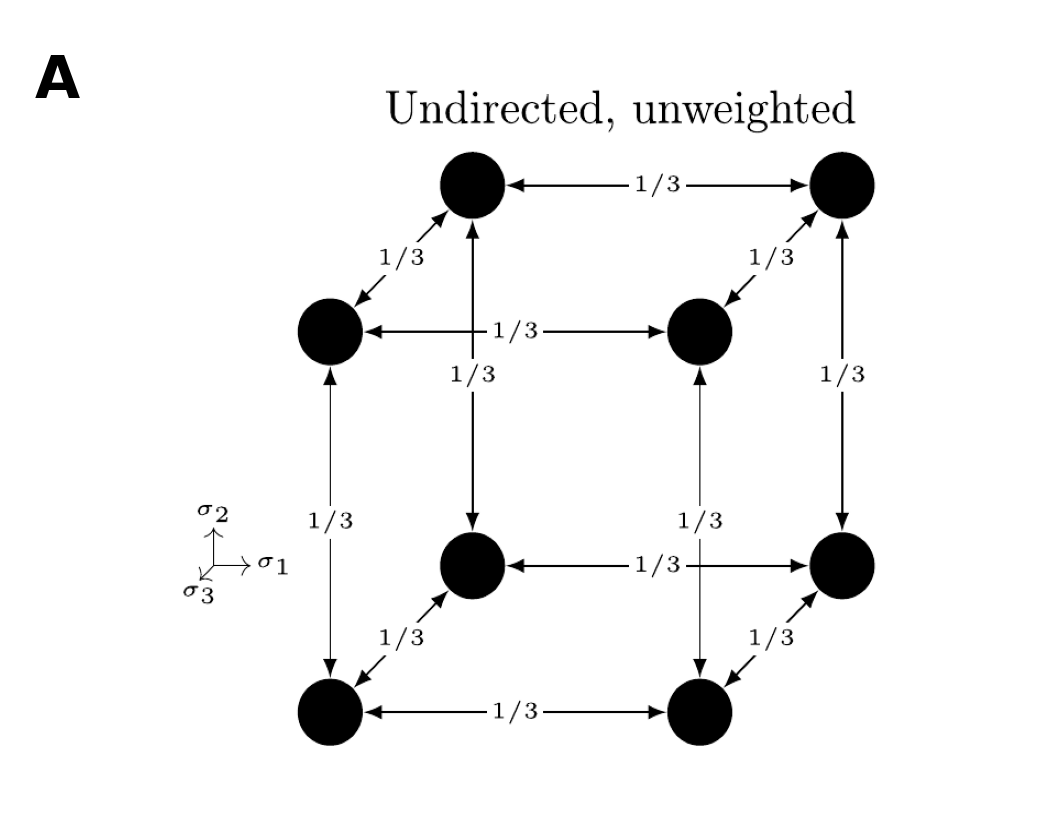

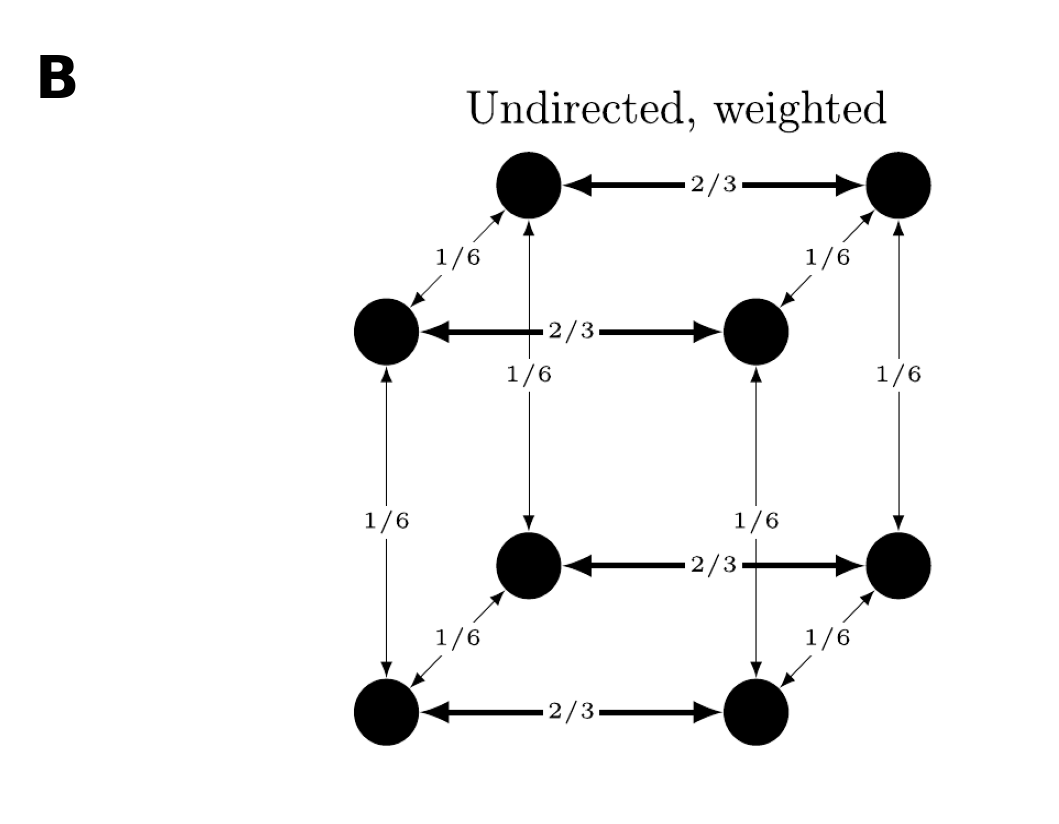

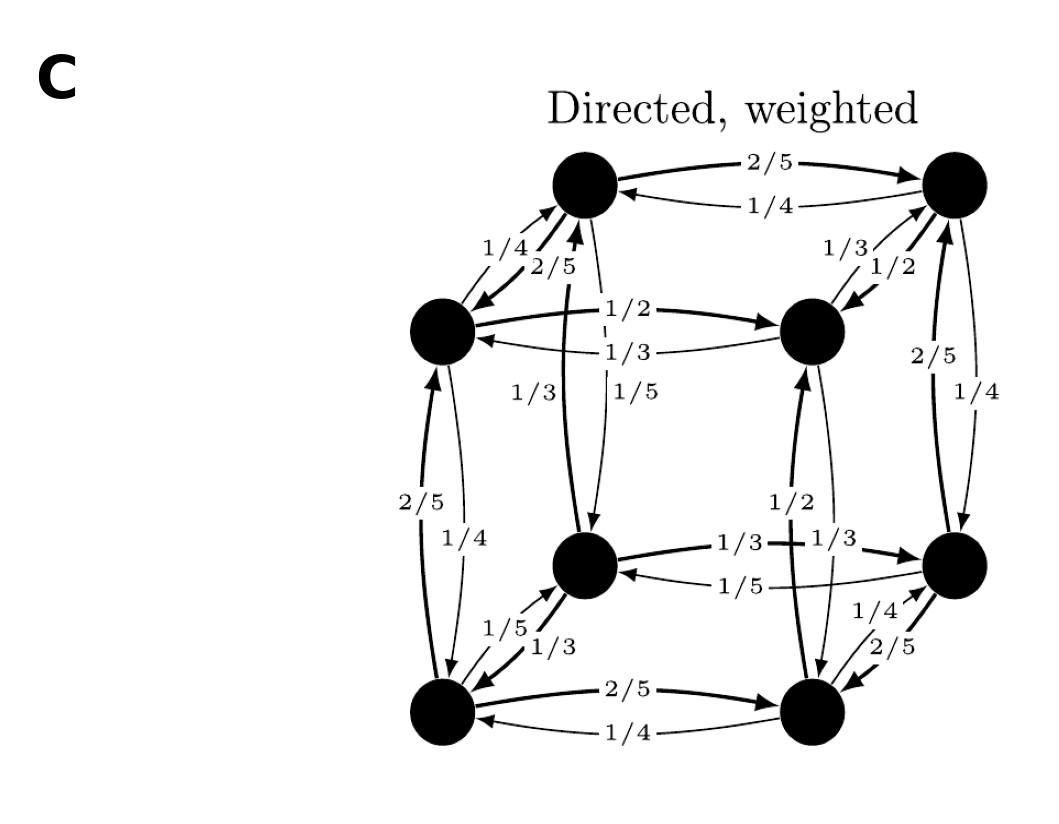

In [8]:
for column, letter in enumerate("ABC"):
    left = round(column * mutation_graph_width / 3)
    right = round((column + 1) * mutation_graph_width / 3)
    fig, ax = plt.subplots(figsize=(3.2, 2.8), dpi=PANEL_DPI)
    ax.imshow(mutation_graph_image[:, left:right], aspect="auto")
    ax.axis("off")
    ax.text(
        -0.14,
        0.9,
        letter,
        transform=ax.transAxes,
        fontsize=PANEL_LETTER_SIZE,
        fontweight="bold",
        ha="left",
        va="bottom",
    )
    if SAVE_FIGURES:
        save_figure(fig, f"figure_6_new{letter}")
    plt.show()


## Individual Panels D--F

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


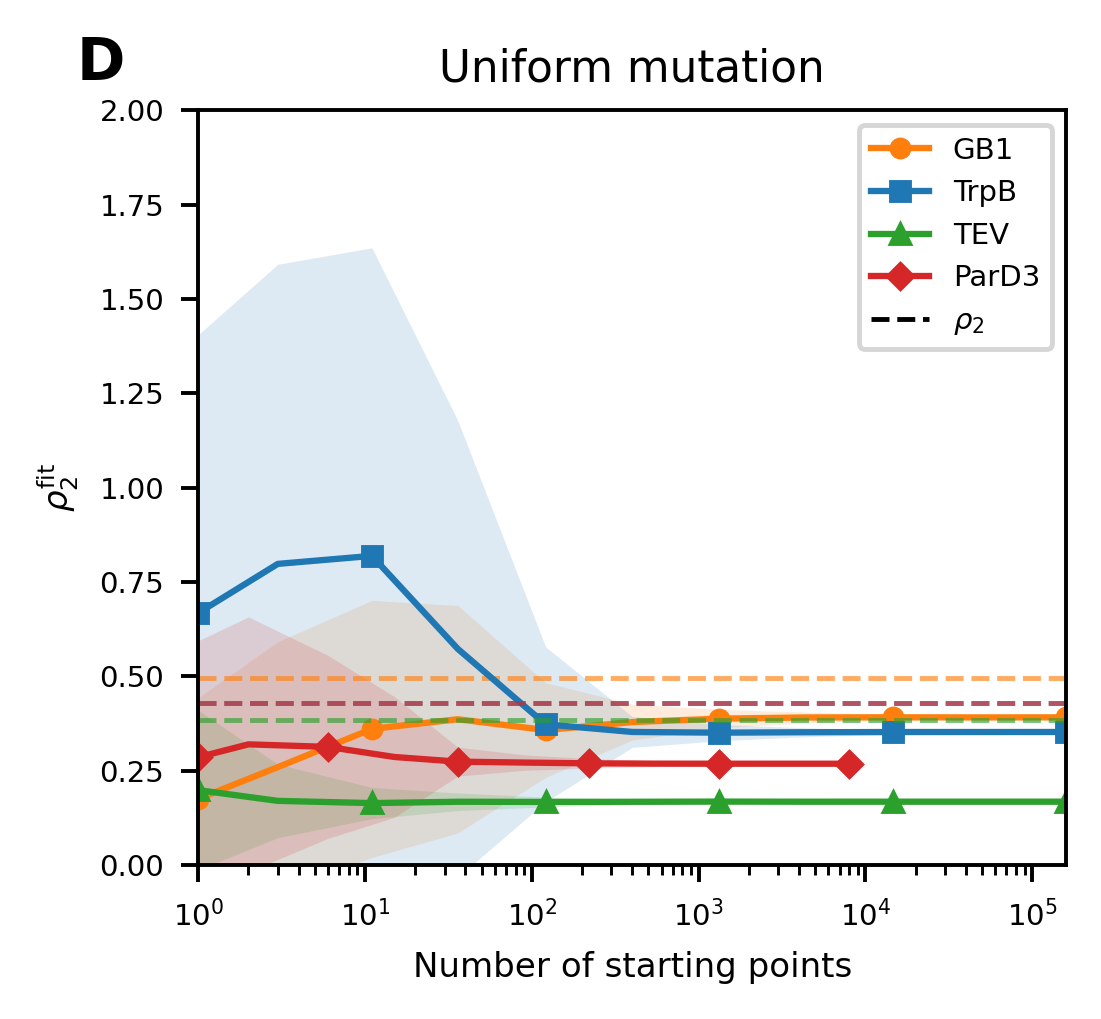

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


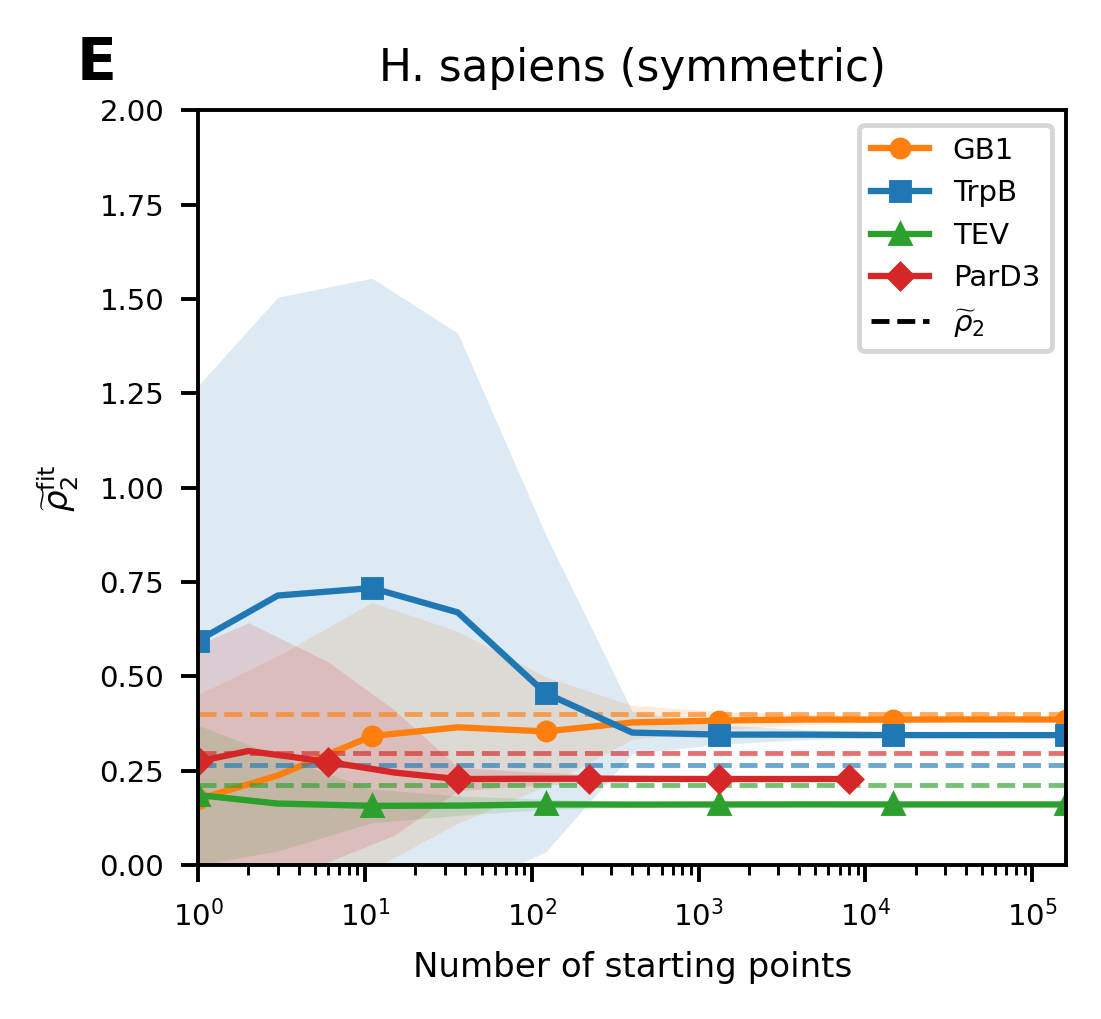

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


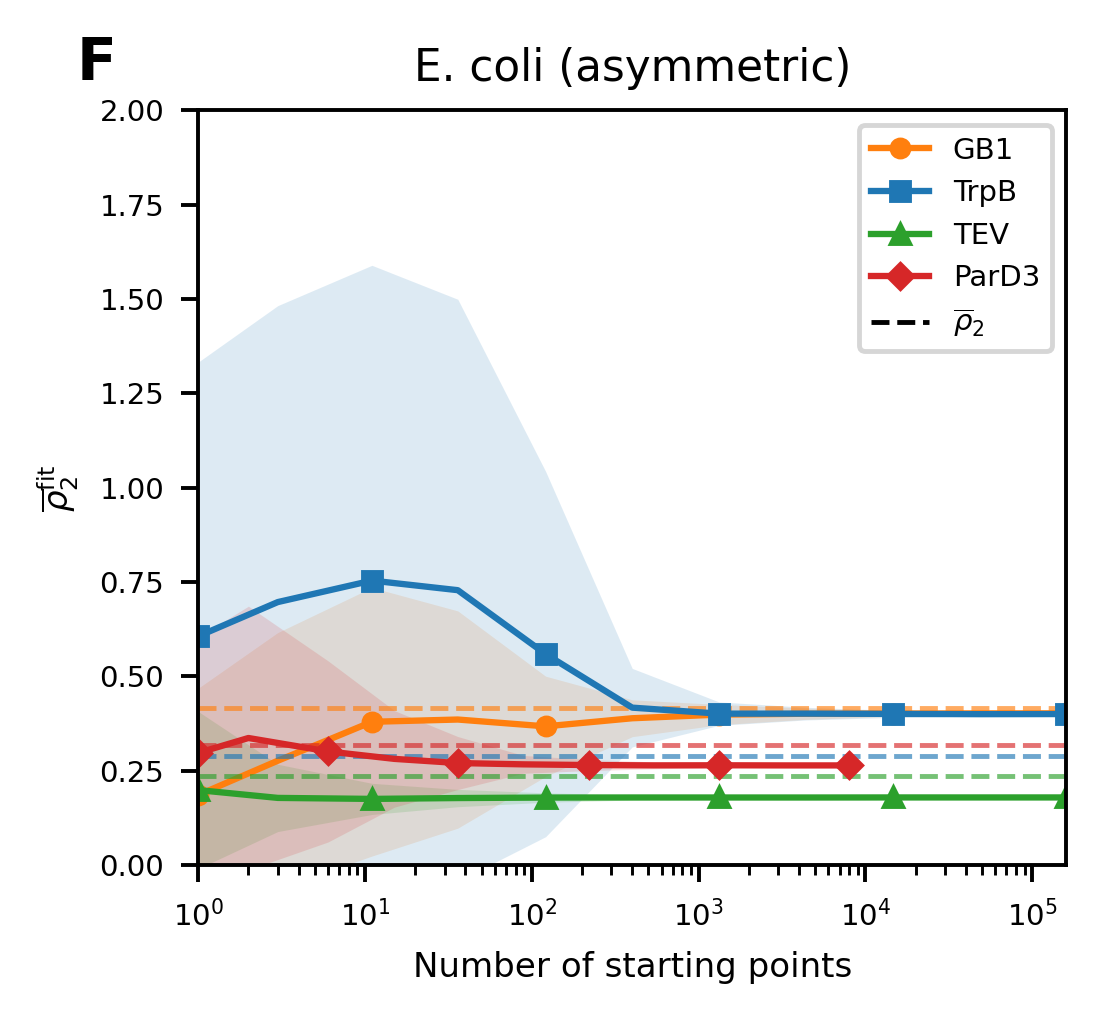

In [9]:
for letter, model in zip("DEF", MUTATION_MODELS, strict=True):
    fig, ax = plt.subplots(figsize=(3.2, 2.8), dpi=PANEL_DPI)
    plot_sampling_accuracy(ax, figure6_sampling_payload, model)
    add_panel_letter(ax, letter)
    if SAVE_FIGURES:
        save_figure(fig, f"figure_6_new{letter}")
    plt.show()


## Individual Panels G--H

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


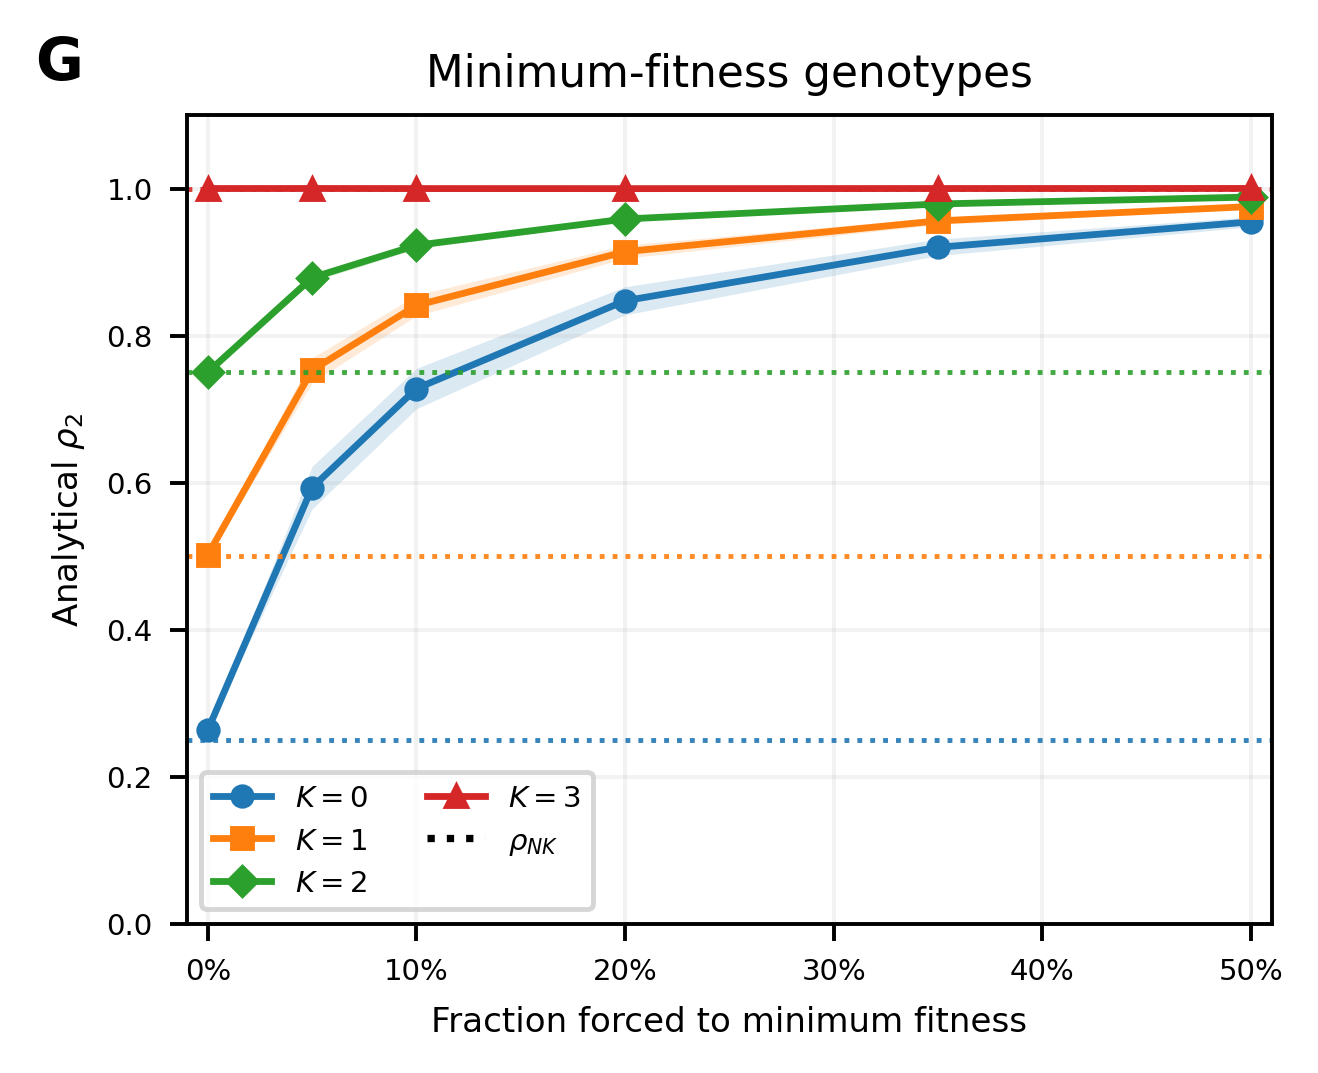

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


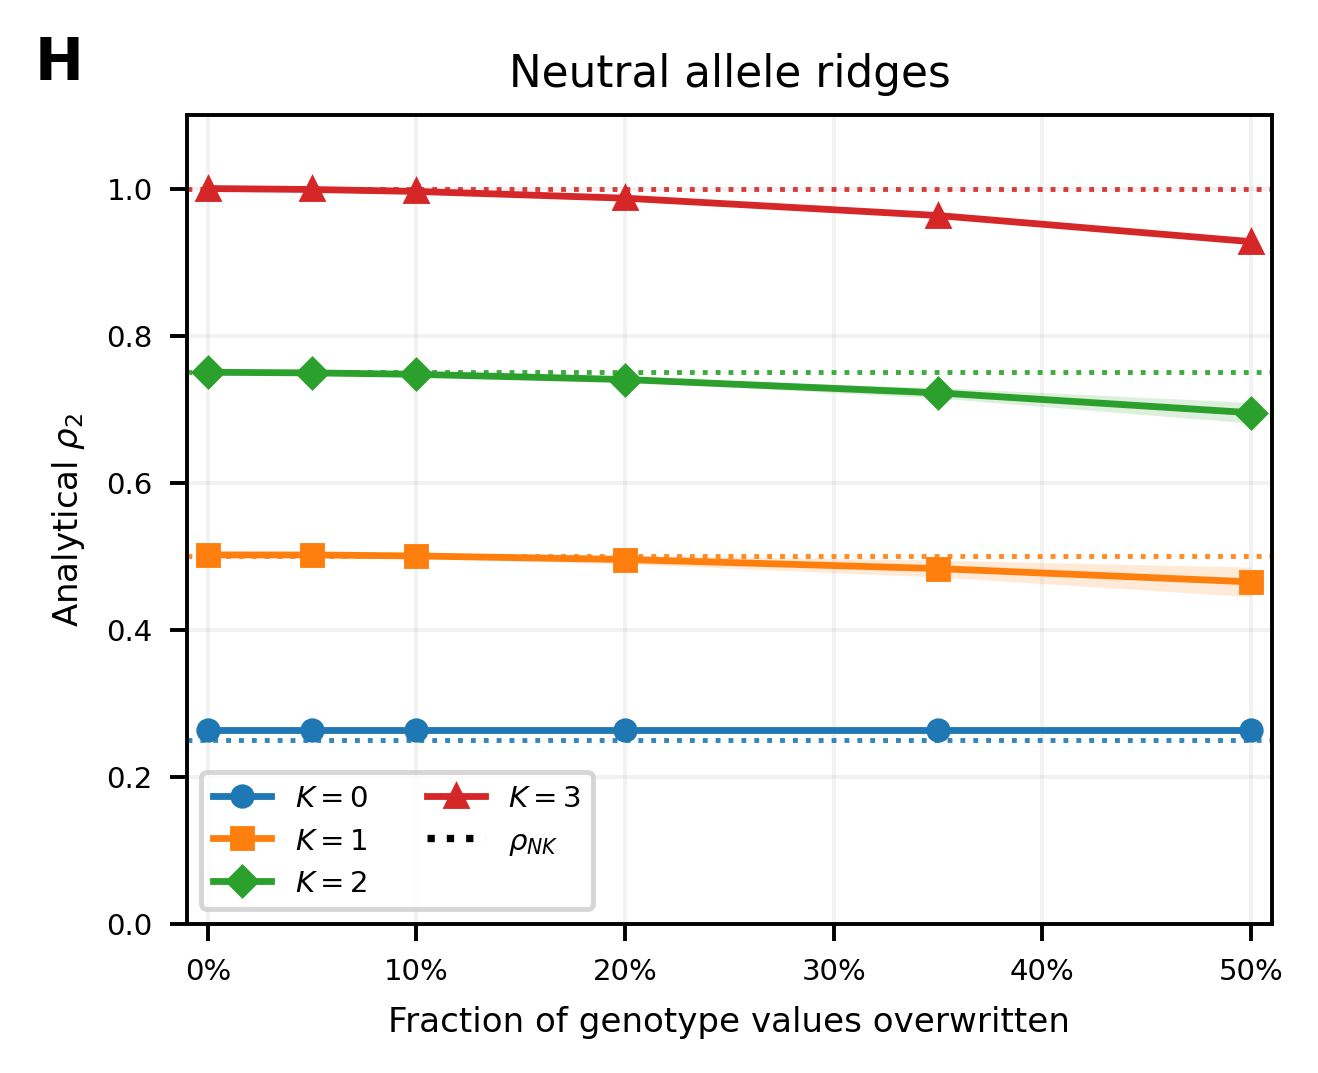

In [ ]:

def plot_figure6_new_rho2_panel(
    ax: Axes,
    payload: dict[str, object],
    decay_payload: dict[str, object],
    perturbation: str,
) -> None:
    """Plot analytical rho_2 against a controlled landscape perturbation.

    Parameters:
    - ax: Axes
        Axis receiving the plot.
    - payload: dict[str, object]
        Processed lethal-node and neutral-ridge results.
    - decay_payload: dict[str, object]
        Processed local and pooled fitted decay rates.
    - perturbation: str
        Either ``lethal`` or ``neutral``.

    Returns:
    - None
        Plot artists are added directly to ``ax``.
    """
    if perturbation not in {"lethal", "neutral"}:
        raise ValueError("perturbation must be 'lethal' or 'neutral'.")
    data = payload["data"]
    params = payload["params"]
    fractions = np.asarray(data["fractions"], dtype=float)
    means = np.asarray(data[f"{perturbation}_mean"], dtype=float)
    standard_deviations = np.asarray(data[f"{perturbation}_std"], dtype=float)
    decay_data = decay_payload["data"]
    perturbation_index = PERTURBATIONS.index(perturbation)
    class_means = np.asarray(decay_data["class_mean"], dtype=float)[perturbation_index]
    class_stds = np.asarray(decay_data["class_std"], dtype=float)[perturbation_index]
    pooled_means = np.asarray(decay_data["pooled_mean"], dtype=float)[perturbation_index]
    pooled_stds = np.asarray(decay_data["pooled_std"], dtype=float)[perturbation_index]
    k_values = tuple(int(value) for value in params["K_values"])
    n_sites = int(params["N"])
    colors = ("tab:blue", "tab:orange", "tab:green", "tab:red")
    markers = ("o", "s", "D", "^")

    for k_index, k_value in enumerate(k_values):
        color = colors[k_index]
        ax.plot(
            fractions,
            means[k_index],
            color=color,
            marker=markers[k_index],
            linewidth=1.4,
            markersize=4,
            label=rf"$K={k_value}$",
        )
        ax.fill_between(
            fractions,
            means[k_index] - standard_deviations[k_index],
            means[k_index] + standard_deviations[k_index],
            color=color,
            alpha=0.16,
            linewidth=0,
        )
        fitted_series = (
            (class_means[k_index, :, 0], class_stds[k_index, :, 0], "--"),
            (class_means[k_index, :, 1], class_stds[k_index, :, 1], "-."),
            (pooled_means[k_index], pooled_stds[k_index], (0, (3, 1, 1, 1))),
        )
        for fitted_mean, fitted_std, line_style in fitted_series:
            ax.plot(
                fractions, fitted_mean, color=color, marker=markers[k_index],
                linestyle=line_style, linewidth=1.15, markersize=3.2,
            )
            ax.fill_between(
                fractions, fitted_mean - fitted_std, fitted_mean + fitted_std,
                color=color, alpha=0.07, linewidth=0,
            )
        ax.axhline(
            (k_value + 1) / n_sites,
            color=color,
            linestyle=":",
            linewidth=1.0,
            alpha=0.9,
        )

    k_handles = [
        mlines.Line2D([], [], color=colors[index], marker=markers[index],
                      linestyle="-", label=rf"$K={k_value}$")
        for index, k_value in enumerate(k_values)
    ]
    estimator_handles = [
        mlines.Line2D([], [], color="black", linestyle="-", label=r"Analytical $\rho_2$"),
        mlines.Line2D([], [], color="black", linestyle="--", label=r"Near-average $\rho_2^{\mathrm{loc}}$"),
        mlines.Line2D([], [], color="black", linestyle="-.", label=r"High-fitness $\rho_2^{\mathrm{loc}}$"),
        mlines.Line2D([], [], color="black", linestyle=(0, (3, 1, 1, 1)), label=r"All-start $\rho_2^{\mathrm{fit}}$"),
        mlines.Line2D([], [], color="black", linestyle=":", label=r"$\rho_{NK}$"),
    ]
    ax.legend(
        handles=k_handles + estimator_handles,
        fontsize=FIGURE_LEGEND_SIZE,
        ncol=2,
        frameon=True,
        loc="best",
    )
    if perturbation == "lethal":
        ax.set_title(rf"Minimum-fitness genotypes (N={N_SITES}, A={NUM_ALLELES})", fontsize=FIGURE_TITLE_SIZE)
        ax.set_xlabel("Fraction forced to minimum fitness", fontsize=FIGURE_LABEL_SIZE)
    else:
        ax.set_title(rf"Neutral allele ridges (N={N_SITES}, A={NUM_ALLELES})", fontsize=FIGURE_TITLE_SIZE)
        ax.set_xlabel("Fraction of genotype values overwritten", fontsize=FIGURE_LABEL_SIZE)
    ax.set_ylabel(r"$\rho_2$", fontsize=FIGURE_LABEL_SIZE)
    ax.set_xlim(-0.01, 0.51)
    upper_limit = 1.05 * max(
        1.10,
        float(np.nanmax(means + standard_deviations)),
        float(np.nanmax(class_means + class_stds)),
        float(np.nanmax(pooled_means + pooled_stds)),
    )
    ax.set_ylim(0.0, upper_limit)
    ax.xaxis.set_major_formatter(PercentFormatter(xmax=1.0, decimals=0))
    ax.tick_params(labelsize=FIGURE_TICK_SIZE)
    ax.grid(True, alpha=0.16)

for letter, perturbation in zip("GH", ("lethal", "neutral"), strict=True):
    fig, ax = plt.subplots(figsize=(4.0, 3.0), dpi=PANEL_DPI)
    plot_figure6_new_rho2_panel(
        ax, figure6_new_payload, figure6_decay_processed, perturbation
    )
    add_panel_letter(ax, letter)
    if SAVE_FIGURES:
        save_figure(fig, f"figure_6_new{letter}")
    plt.show()


## Complete Figure 6 New A--H

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


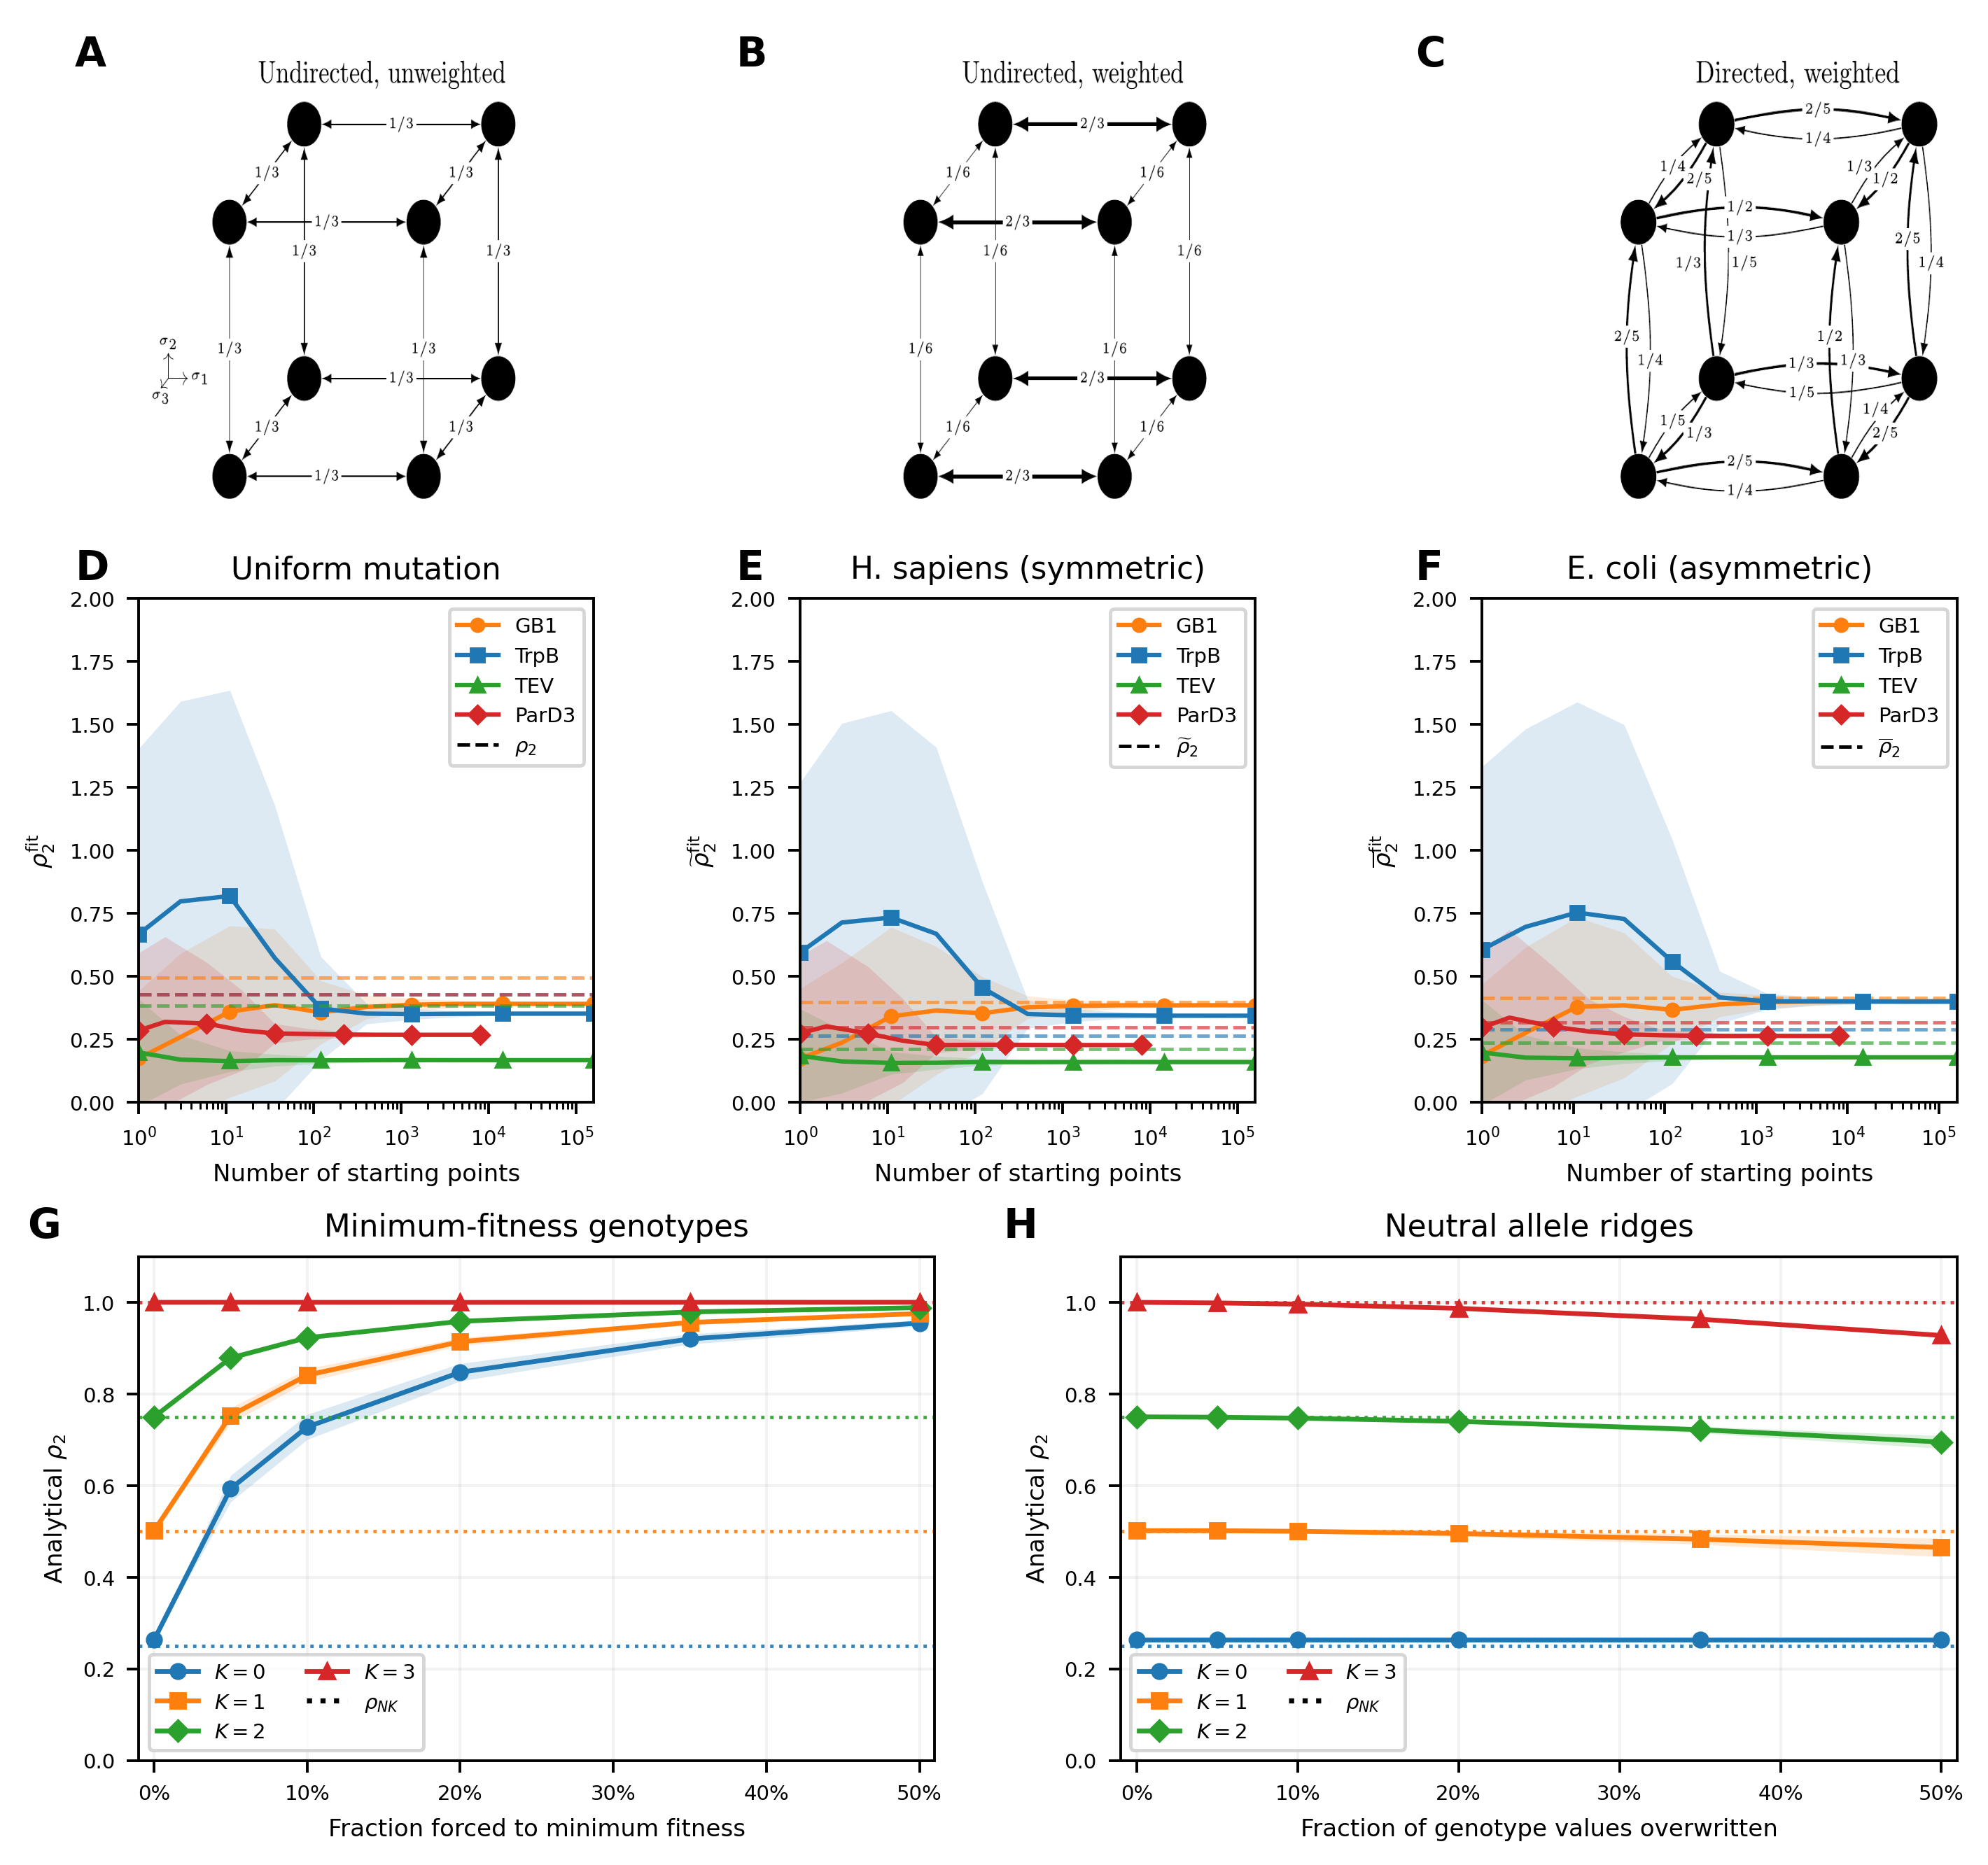

In [11]:
fig = plt.figure(figsize=(8, 7.5), dpi=PANEL_DPI, constrained_layout=True)
grid = GridSpec(3, 6, figure=fig, height_ratios=[1.0, 1.0, 1.0])

graph_axes = [fig.add_subplot(grid[0, 2 * column:2 * column + 2]) for column in range(3)]
for column, (graph_ax, letter) in enumerate(zip(graph_axes, "ABC", strict=True)):
    left = round(column * mutation_graph_width / 3)
    right = round((column + 1) * mutation_graph_width / 3)
    graph_ax.imshow(mutation_graph_image[:, left:right], aspect="auto")
    graph_ax.axis("off")
    graph_ax.text(
        -0.14,
        0.9,
        letter,
        transform=graph_ax.transAxes,
        fontsize=PANEL_LETTER_SIZE,
        fontweight="bold",
        ha="left",
        va="bottom",
    )

sampling_axes = [fig.add_subplot(grid[1, 2 * column:2 * column + 2]) for column in range(3)]
for ax, letter, model in zip(sampling_axes, "DEF", MUTATION_MODELS, strict=True):
    plot_sampling_accuracy(ax, figure6_sampling_payload, model)
    add_panel_letter(ax, letter)

rho_axes = [fig.add_subplot(grid[2, :3]), fig.add_subplot(grid[2, 3:])]
for ax, letter, perturbation in zip(
    rho_axes,
    "GH",
    ("lethal", "neutral"),
    strict=True,
):
    plot_figure6_new_rho2_panel(
        ax, figure6_new_payload, figure6_decay_processed, perturbation
    )
    add_panel_letter(ax, letter)

if SAVE_FIGURES:
    save_figure(fig, "figure_6_new")
plt.show()
